In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import cftime

from ep_processing import *
from loading_helpers import join_paths_areacell

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

Testing that the processing code actually works...

In [2]:
my_experiment_name = "amip"
my_runid = "agm-sm04-alpha-2e10"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [5]:
da_ep_total, da_ep_convective, da_ep_resolved = get_ep_info(my_runid, my_experiment_name, year_range)
da_ep_resolved_max = da_ep_resolved.max().values

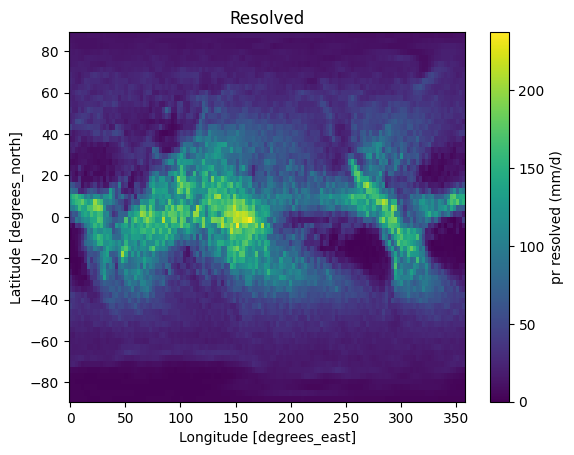

In [3]:
fig, ax = plt.subplots()
CS = da_ep_resolved.plot(vmin=0, vmax=da_ep_resolved_max, cbar_kwargs={"label": "pr resolved (mm/d)"})
plt.title("Resolved")
plt.show()

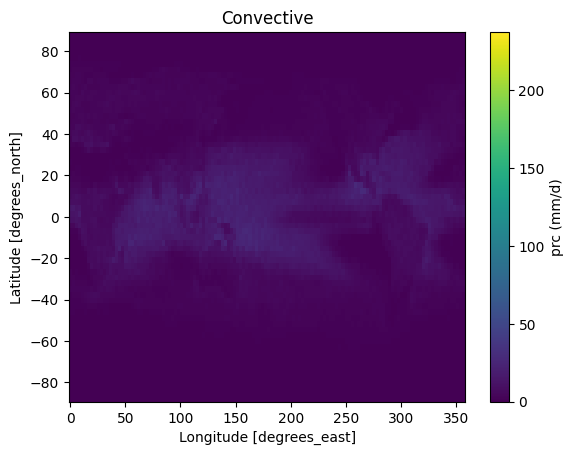

In [4]:
da_ep_convective.plot(vmin=0, vmax=da_ep_resolved_max, cbar_kwargs={"label": "prc (mm/d)"})
plt.title("Convective")
plt.show()

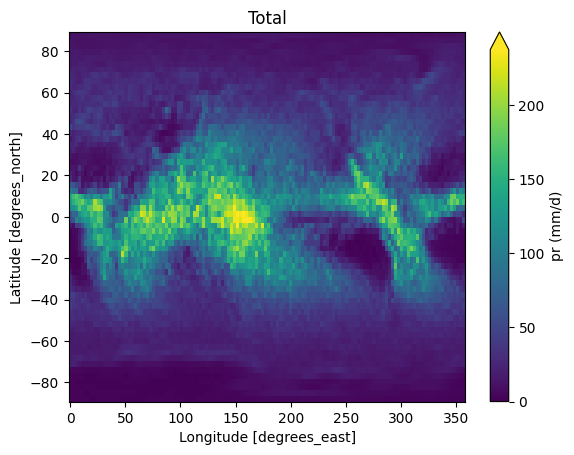

In [5]:
da_ep_total.plot(vmin=0, vmax=da_ep_resolved_max, cbar_kwargs={"label": "pr (mm/d)"})
plt.title("Total")
plt.show()

array(2.9273832, dtype=float32)

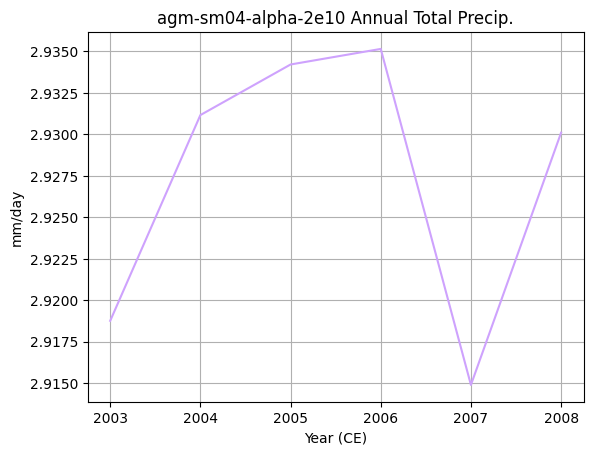

In [7]:
mean_annual_pr_time_series = 86400 * get_annual_mean_time_series("pr", my_runid, my_experiment_name, year_range)
mean_annual_pr_time_series.plot(color="xkcd:lilac")
plt.grid()
plt.title("agm-sm04-alpha-2e10 Annual Total Precip.")
plt.xlabel("Year (CE)")
plt.ylabel("mm/day")
pr_mean = mean_annual_pr_time_series.mean(dim='year').values
pr_mean

## Scinocca-McFarlane Experiments on Max PR

Get baseline data: 

In [9]:
baseline_runid = "agm-amip-test"
pr_total_baseline, pr_convective_baseline, pr_resolved_baseline = get_tropical_areamean_from_experiment(baseline_runid, my_experiment_name, year_range)

### $\alpha$ Experiments 

In [2]:
alpha_str = ["2e6", "2e7", "2e8", "5e8", "2e9", "2e10"] 
alpha = [float(a_str) for a_str in alpha_str]

In [11]:
pr_total_alpha = []
pr_convective_alpha = []
pr_resolved_alpha = []

for a_str in alpha_str:
    if a_str == "5e8":
        pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = pr_total_baseline, pr_convective_baseline, pr_resolved_baseline
    else: 
        sm_runid = "agm-sm04-alpha-" + a_str
        pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = get_tropical_ep_areamean_from_experiment(sm_runid, 
                                                                                                                      my_experiment_name,
                                                                                                                      year_range,
                                                                                                                     )
    
    pr_total_alpha.append(pr_total_experiment)
    pr_convective_alpha.append(pr_convective_experiment)
    pr_resolved_alpha.append(pr_resolved_experiment)

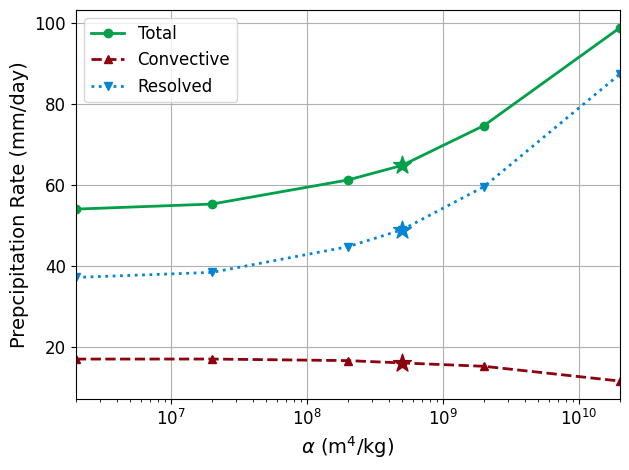

In [43]:
plt.semilogx(alpha, 
             pr_total_alpha, 
             color = "xkcd:emerald", 
             marker = "o", 
             linestyle = "solid", 
             label= "Total", 
             linewidth = 2,
            )
plt.semilogx(alpha, 
             pr_convective_alpha, 
             color = "xkcd:crimson",
             marker = "^", 
             linestyle = "dashed", 
             label = "Convective",
             linewidth = 2,
            )
plt.semilogx(alpha,
             pr_resolved_alpha, 
             color = "xkcd:cerulean",
             marker = "v",
             linestyle = "dotted", 
             label = "Resolved",
             linewidth = 2,
            )

plt.scatter(5e8, 
            pr_total_baseline, 
            color = "xkcd:emerald",
            marker= "*", 
            s = 180,
           )
plt.scatter(5e8, 
            pr_convective_baseline, 
            color = "xkcd:crimson", 
            marker= "*", 
            s = 180,
           )
plt.scatter(5e8, 
            pr_resolved_baseline, 
            color = "xkcd:cerulean", 
            marker= "*", 
            s = 180,
           )

plt.ylabel("Prepcipitation Rate (mm/day)", fontsize = 14)
plt.xlabel(r"$\alpha$ ($\mathrm{m}^4$/kg)", fontsize = 14)
plt.grid("on")
plt.xticks(fontsize = 12, rotation = 0)
plt.yticks(fontsize = 12, rotation = 0)
plt.legend(fontsize = 12)
plt.xlim(min(alpha), max(alpha))
plt.tight_layout()

plt.savefig("sm-experiments-alpha" + ".png", dpi = 600)
plt.show()

### $\tau_\mathrm{d}$ Experiments

In [13]:
taud_str = ["12e2", "8e3", "148e2", "21600", "284e2"]
taud = [float(t_str) for t_str in taud_str]

In [14]:
pr_total_taud = []
pr_convective_taud = []
pr_resolved_taud = []

for t_str in taud_str:
    if t_str == "21600":
        pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = pr_total_baseline, pr_convective_baseline, pr_resolved_baseline        

    else: 
        sm_runid = "agm-sm04-taud-" + t_str
        pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = get_tropical_ep_areamean_from_experiment(sm_runid, my_experiment_name, year_range)
    
    pr_total_taud.append(pr_total_experiment)
    pr_convective_taud.append(pr_convective_experiment)
    pr_resolved_taud.append(pr_resolved_experiment)

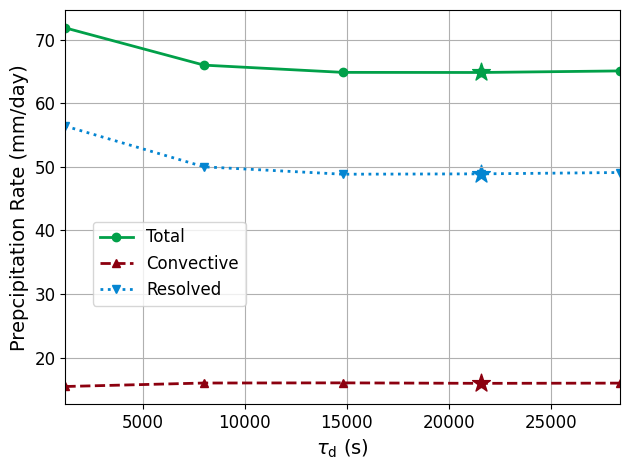

In [42]:
plt.plot(taud, 
         pr_total_taud, 
         color = "xkcd:emerald", 
         marker = "o",
         linestyle = "solid", 
         label= "Total", 
         linewidth = 2,
        )
plt.plot(taud, 
         pr_convective_taud, 
         color = "xkcd:crimson",
         marker = "^",
         linestyle = "dashed",
         label = "Convective",
         linewidth = 2,
        )
plt.plot(taud, 
         pr_resolved_taud, 
         color = "xkcd:cerulean",
         marker = "v",
         linestyle = "dotted", 
         label = "Resolved",
         linewidth = 2,
        )

plt.scatter(21600, 
            pr_total_baseline,
            color = "xkcd:emerald",
            marker= "*", 
            s = 180,
           )
plt.scatter(21600, 
            pr_convective_baseline,
            color = "xkcd:crimson",
            marker= "*",
            s = 180,)
plt.scatter(21600, 
            pr_resolved_baseline, 
            color = "xkcd:cerulean", 
            marker= "*",
            s = 180,
           )

plt.grid("on")
plt.xticks(fontsize = 12, rotation = 0)
plt.yticks(fontsize = 12, rotation = 0)
plt.ylabel("Prepcipitation Rate (mm/day)", fontsize = 14)
plt.xlabel(r"$\tau_{\mathrm{d}}$ (s)", fontsize = 14)
plt.legend(fontsize = 12, loc = (0.05, 0.25))
plt.xlim(min(taud), max(taud))
plt.tight_layout()

plt.savefig("sm-experiments-taud" + ".png", dpi = 600)
plt.show()

*TODO*: Check out Means Instead of Extremes...